> **Dataset-robustness annex - Sinus dataset.** This notebook is an
> *exact* copy of `../imbalance_experiments.ipynb` (Case Study 2): same grid
> (2 noise levels x 8 models x 7 ratios x 12 seeds), same models, same splits,
> same hyperparameters, same analysis code and same statistical protocol
> (Friedman + Wilcoxon + Holm). **Only the base dataset changes**: it is drawn
> from `toy_datasets.make_sinus` (Points above/below f(x1) = -0.8 sin(pi x1).) instead of `make_moons`,
> so every number here is directly comparable to the main study. Results load
> from `results/annex_sinus.json` (produce it with `python run_annex.py sinus`).


# QML vs. Classical Models on Imbalanced `sinus`

**Goal.** Quantify whether the three quantum architectures explored in
`VQC_Autodiff_and_ParameterShift.ipynb` (Fixed VQC, Trainable VQC, Data
Reuploading) offer any meaningful advantage over capacity-matched classical
baselines as class imbalance becomes severe, and whether the conclusion
transfers from a low-overlap dataset to a higher-overlap one.

This notebook drives the experiment matrix end-to-end:

| Axis | Values |
|------|--------|
| Dataset (noise level of `sinus`) | `0.1` (low overlap), `0.3` (substantial overlap) |
| Imbalance ratio (majority share of TRAIN) | 0.50 / 0.60 / 0.70 / 0.80 / 0.90 / 0.95 / 0.99 |
| Quantum models | `data_reuploading`, `fixed_vqc`, `trainable_vqc` |
| Classical models | `logreg`, `svm_rbf`, `knn`, `rf`, `mlp_small` |
| Imbalance handler | `class_weight` (cost-sensitive, only) |
| Seeds | 12 (0..11) |

**Why only `class_weight`?** Holding the imbalance-handling strategy fixed
removes a confound: any difference between quantum and classical balanced
accuracy reflects the model itself, not handler-specific interactions.
`class_weight` is also the cheapest possible handler — a per-sample weight
factor on each residual, no synthetic samples, no resampling.

**Why two noise levels?** `sinus(noise=0.1)` is geometrically simple and
kernel methods saturate near 1.0 BA, which makes it a "toy" testbed.
`sinus(noise=0.3)` overlaps the two classes substantially: the
Bayes-optimal classifier sits well below 1.0 BA and no method can recover the
original geometry exactly. The two-dataset design tests whether the
conclusion of the low-overlap case transfers to a regime where the kernel
methods lose their structural advantage.

**Validation and test sets are kept balanced** — only TRAIN is imbalanced.
This isolates the effect of training imbalance on generalisation to the true
distribution and makes balanced accuracy measure exactly that.

**Threshold tuning on validation.** All models output a continuous score; the
decision threshold is picked on val to maximise balanced accuracy and then
applied unchanged to test.

**Library.** All the heavy lifting (quantum forwards, parameter-shift training,
class-weight handling, baselines, metrics, statistical tests) lives in
`qml_imbalance.py`. This notebook is the driver and the visualisation.

## Pre-registered analysis criteria

These are decided **before** looking at the results to avoid post-hoc
rationalisation.

**Primary outcome.** Mean **balanced accuracy (BA)** on the held-out test
set, averaged across the 12 seeds, after threshold tuning on val. BA is the
single metric of the thesis: it penalises trivial majority predictors,
treats the two classes symmetrically, and is the canonical choice for
imbalanced binary classification.

**Quantum-advantage criterion (per dataset and imbalance ratio).** A quantum
model $M_q$ has a meaningful advantage over a classical model $M_c$ at noise
level $\eta$ and ratio $r$ if **both** of the following hold under the paired
non-parametric protocol described by Demšar (2006) and García & Herrera (2008):

1. The **Friedman omnibus test** rejects $H_0$ "all $k$ algorithms perform
   equivalently" at $\alpha = 0.05$, applied to the
   $n_\text{seeds} \times k$ matrix of per-seed BA scores at that
   $(\eta, r)$.
2. The **Wilcoxon signed-rank test** for the paired sequence
   $\{\mathrm{BA}_s(M_q) - \mathrm{BA}_s(M_c)\}_{s=1}^{n_\text{seeds}}$,
   after **Holm step-down correction** for the family of $k(k{-}1)/2 = 28$
   pairwise tests, yields $p_\text{Holm} < 0.05$ with the mean difference in
   favour of $M_q$.

The Friedman step controls the type-I error of the omnibus question (are any
models different?); the Holm-adjusted Wilcoxon step controls the family-wise
error rate of the pairwise follow-up (which pairs differ?) without the
over-conservatism of Bonferroni. This is implemented in
`qi.friedman_wilcoxon_holm` and is the basis for the advantage tables
reported below.

**Why 12 seeds.** The discrete distribution of the Wilcoxon signed-rank test
has a smallest two-sided $p$-value of $2/2^n$ at $n$ seeds. With $k = 8$
models and the family of 28 pairwise tests, the smallest Holm-adjusted
$p$-value is $28 \times 2 / 2^n$, which must be below $\alpha = 0.05$
for the protocol to be able to certify any pair. At $n = 10$ the floor is
$0.0547$, *just above* $\alpha$; at $n = 12$ it drops to $0.0137$. The
thesis uses $n = 12$ to lift this floor cleanly below the threshold.

**Robustness criterion.** The robustness slope is
$\Delta := \overline{\mathrm{BA}}(M, r{=}0.5) - \overline{\mathrm{BA}}(M, r{=}0.99)$
at each noise level. Smaller $\Delta$ means the model degrades less under
imbalance. Reported alongside (not in place of) the absolute BA.

## 1. Imports and configuration

In [1]:
import os
import sys
import time
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))
import qml_imbalance as qi
import toy_datasets as td

DATASET = 'sinus'

print('numpy', np.__version__)
print('library:', qi.__file__)

numpy 2.4.6
library: C:\Users\sergi\Documents\Dev\tfm_quatum\tfm_project\code\qml_imbalance.py


In [2]:
CONFIG = dict(
    noise_levels     = [0.1, 0.3],
    n_total_base     = 8000,
    n_train          = 500,
    n_val            = 400,
    n_test           = 1200,
    ratios           = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99],
    seeds            = list(range(12)),
    quantum_iter     = 200,
    quantum_models   = ['data_reuploading', 'fixed_vqc', 'trainable_vqc'],
    classical_models = ['logreg', 'svm_rbf', 'knn', 'rf', 'mlp_small'],
)
ALL_MODELS = CONFIG['quantum_models'] + CONFIG['classical_models']

for k, v in CONFIG.items():
    print(f'  {k:<18} = {v}')

n_runs_per_noise = len(ALL_MODELS) * len(CONFIG['ratios']) * len(CONFIG['seeds'])
n_runs_total = n_runs_per_noise * len(CONFIG['noise_levels'])
print(f'\nRuns per noise level: {n_runs_per_noise}')
print(f'Total runs across both noise levels: {n_runs_total}')

  noise_levels       = [0.1, 0.3]
  n_total_base       = 8000
  n_train            = 500
  n_val              = 400
  n_test             = 1200
  ratios             = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
  seeds              = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
  quantum_iter       = 200
  quantum_models     = ['data_reuploading', 'fixed_vqc', 'trainable_vqc']
  classical_models   = ['logreg', 'svm_rbf', 'knn', 'rf', 'mlp_small']

Runs per noise level: 672
Total runs across both noise levels: 1344


## 2. The two datasets

Both are `sinus` with a 50/50 class balance in the base pool of 8 000
samples; the only difference is the Gaussian noise added to the coordinates.

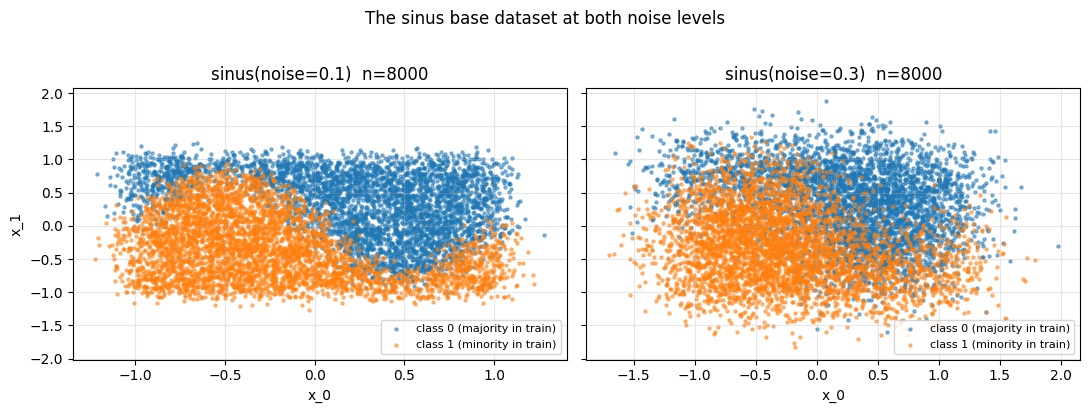

In [3]:
datasets = {}
for noise in CONFIG['noise_levels']:
    X, y = td.make_dataset(
        DATASET, n_samples=CONFIG['n_total_base'], noise=noise, random_state=42)
    datasets[noise] = (X, y)

fig, axes = plt.subplots(1, len(CONFIG['noise_levels']),
                         figsize=(5.5 * len(CONFIG['noise_levels']), 4),
                         sharey=True)
for ax, noise in zip(np.atleast_1d(axes), CONFIG['noise_levels']):
    X, y = datasets[noise]
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=5, alpha=0.5,
               label='class 0 (majority in train)')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=5, alpha=0.5,
               label='class 1 (minority in train)')
    ax.set_title(f'{DATASET}(noise={noise})  n={len(X)}')
    ax.set_xlabel('x_0')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
axes.flat[0].set_ylabel('x_1')
plt.suptitle(f'The {DATASET} base dataset at both noise levels', y=1.02)
plt.tight_layout()
plt.savefig(f'figures/{DATASET}-case2-datasets.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. What does the imbalanced training set look like?

One row per noise level, one column per ratio. Class 1 (minority) gets
sparser as the ratio grows. Val and test are balanced regardless.

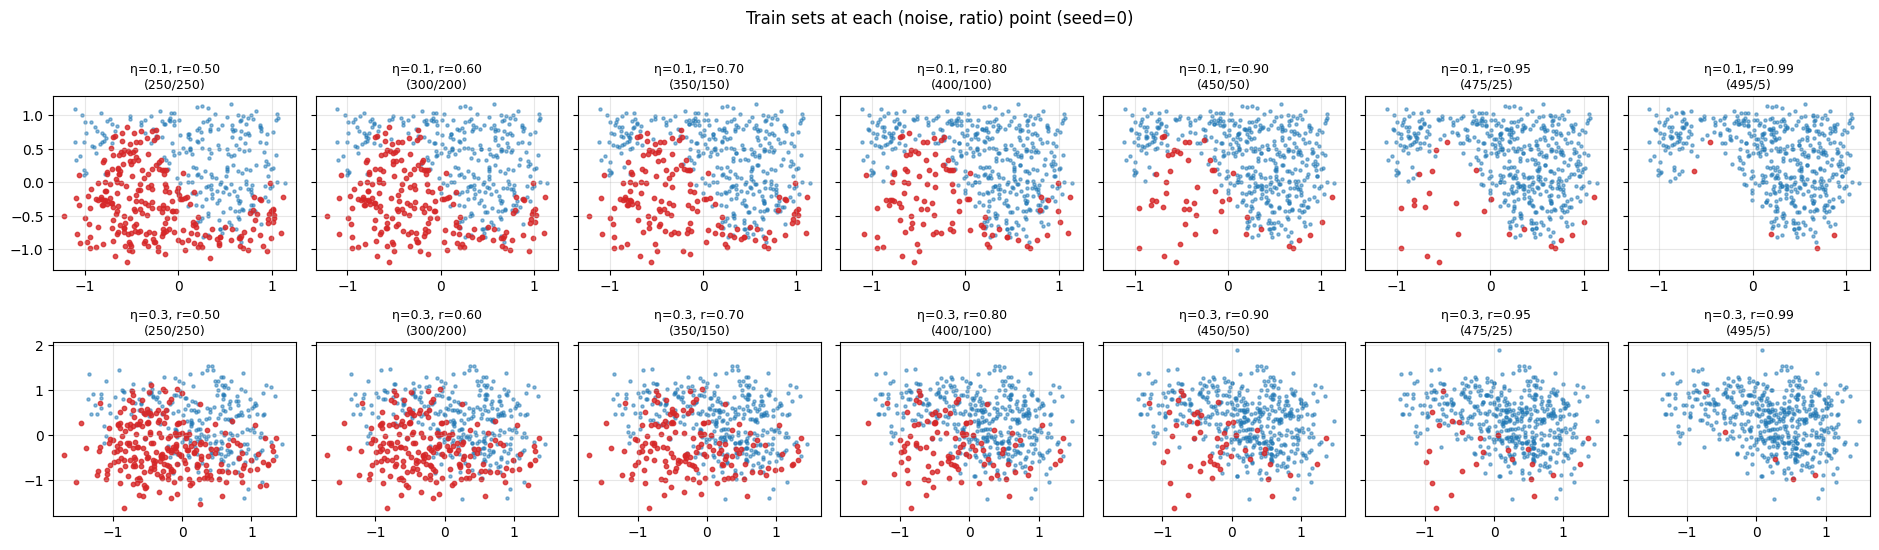

In [4]:
fig, axes = plt.subplots(
    len(CONFIG['noise_levels']), len(CONFIG['ratios']),
    figsize=(2.7 * len(CONFIG['ratios']), 2.7 * len(CONFIG['noise_levels'])),
    sharex='row', sharey='row')

for i, noise in enumerate(CONFIG['noise_levels']):
    X_base, y_base = datasets[noise]
    for j, r in enumerate(CONFIG['ratios']):
        ax = axes[i, j]
        Xt, yt, *_ = qi.make_imbalanced_split(
            X_base, y_base, train_ratio_majority=r,
            n_train=CONFIG['n_train'], n_val=CONFIG['n_val'],
            n_test=CONFIG['n_test'], seed=0)
        n0 = int((yt == 0).sum()); n1 = int((yt == 1).sum())
        ax.scatter(Xt[yt == 0, 0], Xt[yt == 0, 1], s=5, alpha=0.5, c='#1f77b4')
        ax.scatter(Xt[yt == 1, 0], Xt[yt == 1, 1], s=10, alpha=0.8, c='#d62728')
        ax.set_title(f'η={noise}, r={r:.2f}\n({n0}/{n1})', fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle('Train sets at each (noise, ratio) point (seed=0)', y=1.01)
plt.tight_layout()
plt.savefig(f'figures/{DATASET}-case2-train-sets.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Run (or load) the experiment grid

The full grid is 8 models × 7 ratios × 12 seeds × 2 noise levels = **1 344
runs**. Each run is independent and seeded reproducibly. If the cached
results file `results/runs_simplified.json` exists it is loaded; otherwise
the grid runs sequentially (≈70 min on a single CPU core).

Per-task seeding makes the result bit-identical regardless of how it was
computed: 0..11 are the seed values used everywhere.

In [5]:
def model_factory(name):
    if name in qi.QuantumModel.SPEC:
        return qi.QuantumModel(name, n_iter=CONFIG['quantum_iter'])
    return qi.ClassicalModel(name)

RESULTS_PATH = f'results/annex_{DATASET}.json'

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        loaded = json.load(f)
    raw_records = loaded['runs']
    print(f'Loaded {len(raw_records)} cached runs from {RESULTS_PATH}')
else:
    print(f'No cache at {RESULTS_PATH}; running the grid now.')
    raw_records = []
    tasks = [(noise, m, r, s)
             for noise in CONFIG['noise_levels']
             for m in ALL_MODELS
             for r in CONFIG['ratios']
             for s in CONFIG['seeds']]
    t_start = time.time()
    for i, (noise, mname, ratio, seed) in enumerate(tasks, 1):
        X, y = datasets[noise]
        model = model_factory(mname)
        out = qi.run_one(model, ratio=ratio, seed=seed,
                          X_base=X, y_base=y,
                          n_train=CONFIG['n_train'],
                          n_val=CONFIG['n_val'],
                          n_test=CONFIG['n_test'],
                          verbose=False)
        raw_records.append({
            'noise': noise, 'model': out.model, 'ratio': out.ratio,
            'seed': out.seed, 'metrics': out.metrics,
            'threshold': out.threshold, 'fit_time_s': out.fit_time_s,
            'n_circuit_evals': out.n_circuit_evals,
            'n_train_majority': out.n_train_majority,
            'n_train_minority': out.n_train_minority,
        })
        if i % 50 == 0 or i == len(tasks):
            el = time.time() - t_start
            print(f'  [{i:4d}/{len(tasks)}] noise={noise} {mname:<18s} '
                  f'r={ratio:.2f} seed={seed:>2d}  '
                  f'BA={out.metrics["balanced_accuracy"]:.3f}  '
                  f'({el/60:.1f} min elapsed)')
    os.makedirs('results', exist_ok=True)
    with open(RESULTS_PATH, 'w') as f:
        json.dump({'config': CONFIG, 'runs': raw_records}, f,
                  indent=1, default=float)
    print(f'Saved to {RESULTS_PATH}')

# Convert dicts back to RunResult objects (with noise stored separately)
results_by_noise = defaultdict(list)
for r in raw_records:
    rr = qi.RunResult(
        model=r['model'], ratio=r['ratio'], seed=r['seed'],
        metrics=r['metrics'], threshold=r['threshold'],
        fit_time_s=r['fit_time_s'],
        n_circuit_evals=r['n_circuit_evals'],
        n_train_majority=r['n_train_majority'],
        n_train_minority=r['n_train_minority'],
    )
    results_by_noise[r['noise']].append(rr)

for noise, rs in sorted(results_by_noise.items()):
    print(f'noise={noise}: {len(rs)} runs')

Loaded 1344 cached runs from results/annex_sinus.json
noise=0.1: 672 runs
noise=0.3: 672 runs


## 5. Aggregated balanced-accuracy table

One row per (noise, model) showing mean ± std across the 12 seeds at each
imbalance ratio.

In [6]:
for noise in CONFIG['noise_levels']:
    print(f'\n=== noise = {noise} ===')
    agg = qi.aggregate(results_by_noise[noise], by=('model', 'ratio'))
    ratios = sorted(CONFIG['ratios'])
    header = f'{"model":<18s}' + ''.join(f'r={r:.2f}'.rjust(13) for r in ratios)
    print(header)
    print('-' * len(header))
    seen = set()
    for row in agg:
        m = row['model']
        if m in seen:
            continue
        seen.add(m)
        cells_str = f'{m:<18s}'
        for r in ratios:
            match = next((x for x in agg
                          if x['model'] == m and x['ratio'] == r), None)
            cells_str += (f'{match["balanced_accuracy_mean"]:.3f}±'
                          f'{match["balanced_accuracy_std"]:.2f}').rjust(13)
        print(cells_str)


=== noise = 0.1 ===
model                    r=0.50       r=0.60       r=0.70       r=0.80       r=0.90       r=0.95       r=0.99
-------------------------------------------------------------------------------------------------------------
data_reuploading     0.759±0.02   0.752±0.03   0.755±0.03   0.751±0.03   0.742±0.04   0.730±0.03   0.708±0.04
fixed_vqc            0.666±0.02   0.669±0.02   0.665±0.02   0.666±0.02   0.655±0.02   0.655±0.02   0.632±0.03
knn                  0.909±0.01   0.905±0.01   0.903±0.01   0.898±0.02   0.893±0.02   0.871±0.02   0.767±0.02
logreg               0.838±0.01   0.835±0.01   0.834±0.01   0.839±0.01   0.839±0.01   0.836±0.01   0.831±0.02
mlp_small            0.847±0.01   0.845±0.02   0.842±0.02   0.844±0.01   0.837±0.03   0.810±0.08   0.742±0.11
rf                   0.906±0.01   0.905±0.01   0.904±0.01   0.902±0.01   0.893±0.01   0.871±0.02   0.819±0.03
svm_rbf              0.910±0.01   0.912±0.01   0.913±0.01   0.913±0.01   0.909±0.01   0.902±0.02   

## 6. Degradation curves

Headline figure: BA vs imbalance ratio, one panel per noise level. Quantum
models in solid lines, classical in dashed. Shaded bands span ±1 std across
the 12 seeds.

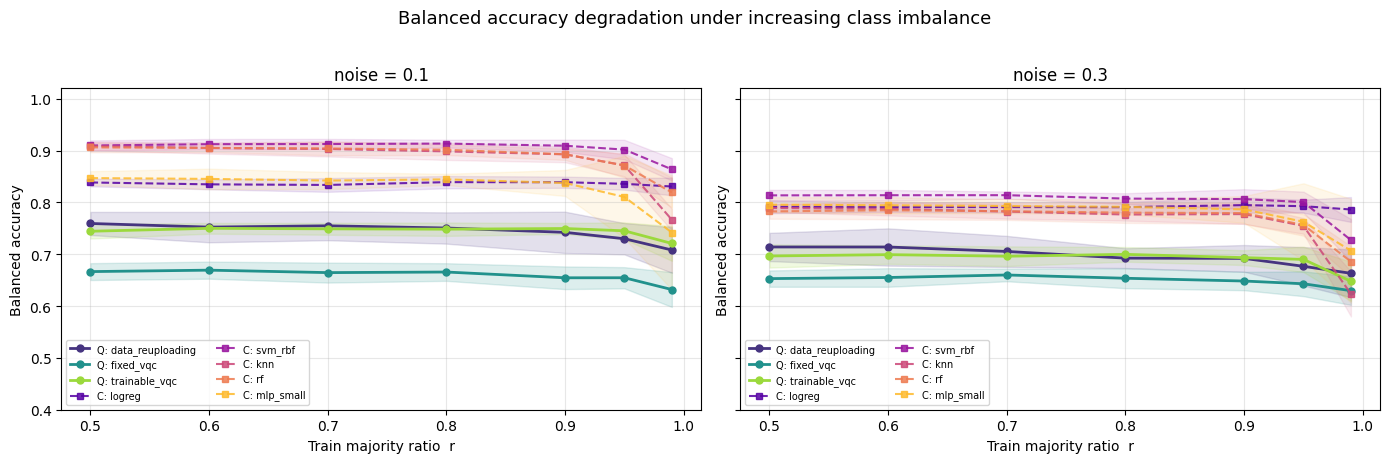

In [7]:
def degradation_plot(noise, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    agg = qi.aggregate(results_by_noise[noise], by=('model', 'ratio'))
    cmap_q = plt.cm.viridis(np.linspace(0.15, 0.85, len(CONFIG['quantum_models'])))
    cmap_c = plt.cm.plasma(np.linspace(0.15, 0.85, len(CONFIG['classical_models'])))

    def collect(mname):
        rs = sorted(CONFIG['ratios'])
        means, stds = [], []
        for r in rs:
            row = next((x for x in agg
                        if x['model'] == mname and x['ratio'] == r), None)
            means.append(row['balanced_accuracy_mean'] if row else np.nan)
            stds.append(row['balanced_accuracy_std'] if row else 0.0)
        return np.array(rs), np.array(means), np.array(stds)

    for mname, color in zip(CONFIG['quantum_models'], cmap_q):
        rs, mu, sd = collect(mname)
        ax.plot(rs, mu, '-o', color=color, linewidth=2,
                markersize=5, label=f'Q: {mname}')
        ax.fill_between(rs, mu - sd, mu + sd, color=color, alpha=0.15)
    for mname, color in zip(CONFIG['classical_models'], cmap_c):
        rs, mu, sd = collect(mname)
        ax.plot(rs, mu, '--s', color=color, linewidth=1.5,
                markersize=4, alpha=0.85, label=f'C: {mname}')
        ax.fill_between(rs, mu - sd, mu + sd, color=color, alpha=0.10)
    ax.set_xlabel('Train majority ratio  r')
    ax.set_ylabel('Balanced accuracy')
    ax.set_title(f'noise = {noise}')
    ax.set_ylim([0.4, 1.02])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left', fontsize=7, ncol=2)
    return ax

fig, axes = plt.subplots(1, len(CONFIG['noise_levels']),
                         figsize=(7 * len(CONFIG['noise_levels']), 4.5),
                         sharey=True)
for ax, noise in zip(np.atleast_1d(axes), CONFIG['noise_levels']):
    degradation_plot(noise, ax=ax)
plt.suptitle('Balanced accuracy degradation under increasing class imbalance',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'figures/{DATASET}-case2-degradation.png',
            dpi=130, bbox_inches='tight')
plt.show()

## 7. Head-to-head at the most extreme ratio

Bar chart of BA at $r = 0.99$, one panel per noise level. Error bars are
±1 std across the 12 seeds. The dashed line at 0.5 marks the trivial
majority predictor.

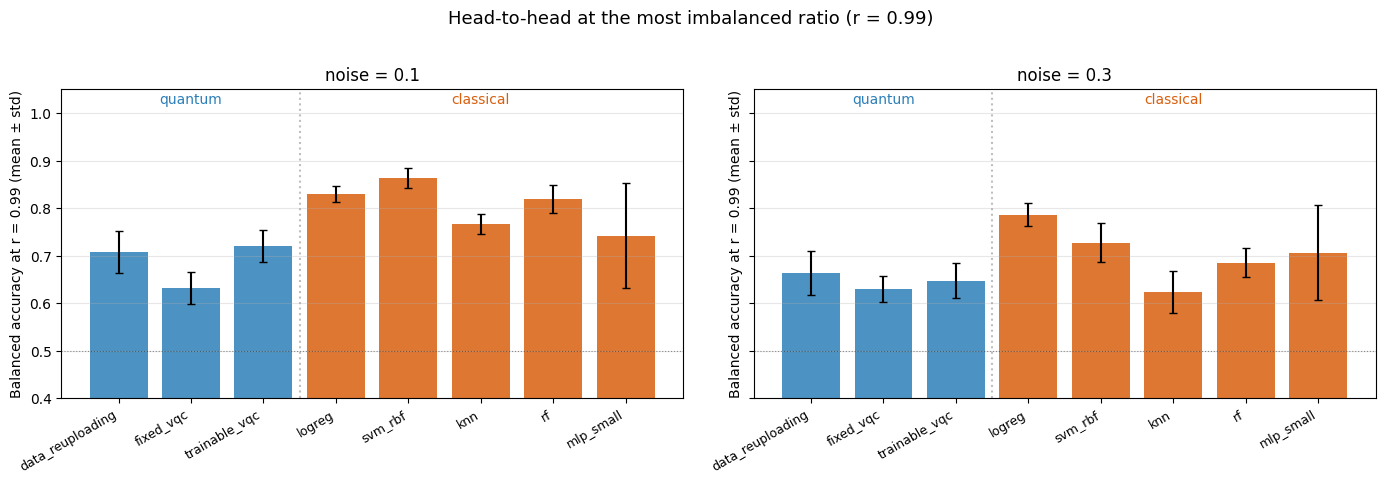

In [8]:
extreme = max(CONFIG['ratios'])

fig, axes = plt.subplots(1, len(CONFIG['noise_levels']),
                         figsize=(7 * len(CONFIG['noise_levels']), 4.7),
                         sharey=True)
for ax, noise in zip(np.atleast_1d(axes), CONFIG['noise_levels']):
    agg = qi.aggregate(results_by_noise[noise], by=('model', 'ratio'))
    means = []
    stds = []
    for m in ALL_MODELS:
        row = next((r for r in agg
                    if r['model'] == m and r['ratio'] == extreme), None)
        means.append(row['balanced_accuracy_mean'] if row else np.nan)
        stds.append(row['balanced_accuracy_std'] if row else 0.0)

    n_q = len(CONFIG['quantum_models'])
    colors = ['#2c7fb8'] * n_q + ['#d95f0e'] * (len(ALL_MODELS) - n_q)
    xs = np.arange(len(ALL_MODELS))
    ax.bar(xs, means, yerr=stds, color=colors, alpha=0.85, capsize=3)
    ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.axvline(n_q - 0.5, color='gray', linestyle=':', alpha=0.5)
    ax.text(n_q / 2 - 0.5, 1.02, 'quantum', ha='center',
            fontsize=10, color='#2c7fb8')
    ax.text((n_q + len(ALL_MODELS)) / 2 - 0.5, 1.02, 'classical',
            ha='center', fontsize=10, color='#d95f0e')
    ax.set_xticks(xs)
    ax.set_xticklabels(ALL_MODELS, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Balanced accuracy at r = 0.99 (mean ± std)')
    ax.set_title(f'noise = {noise}')
    ax.set_ylim([0.4, 1.05])
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Head-to-head at the most imbalanced ratio (r = {extreme:.2f})',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'figures/{DATASET}-case2-headtohead.png',
            dpi=130, bbox_inches='tight')
plt.show()

## 8. Pre-registered protocol: Friedman + Wilcoxon + Holm

The protocol is run **per (noise, ratio)**. For each ratio we report:
* the Friedman omnibus $\chi^2$ and $p$-value;
* the count of pairs (out of 28) where Holm-adjusted $p < 0.05$;
* the full ranked pairwise table at $r = 0.99$ (the operationally most
  interesting point).

The 28-pair family-wise floor at $n_\text{seeds} = 12$ is
$28 \times 2/2^{12} \approx 0.0137 < 0.05$, so the protocol can certify pairs.

In [9]:
print('Friedman omnibus per (noise, ratio):')
print('=' * 78)
print(f'{"noise":<7s} {"r":<6s}  {"chi^2":>10s}  {"p_friedman":>12s}  '
      f'{"# pairs Holm-sig (of 28)":>27s}')
print('-' * 78)
friedman_tables = {}
for noise in CONFIG['noise_levels']:
    stats_per_ratio = qi.friedman_wilcoxon_holm(results_by_noise[noise])
    friedman_tables[noise] = stats_per_ratio
    for r in sorted(stats_per_ratio.keys()):
        st = stats_per_ratio[r]
        if np.isnan(st['friedman_p']):
            print(f'{noise:<7} {r:<6.2f}  {"nan":>10s}  {"nan":>12s}  '
                  f'{"-":>27s}')
            continue
        n_sig = sum(1 for v in st['pairwise'].values()
                    if v['reject_holm'])
        print(f'{noise:<7} {r:<6.2f}  {st["friedman_stat"]:>10.2f}  '
              f'{st["friedman_p"]:>12.3e}  {n_sig:>14d} of 28')
print('=' * 78)

Friedman omnibus per (noise, ratio):
noise   r            chi^2    p_friedman     # pairs Holm-sig (of 28)
------------------------------------------------------------------------------


0.1     0.50         78.94     2.261e-14              23 of 28
0.1     0.60         79.16     2.046e-14              23 of 28
0.1     0.70         79.58     1.675e-14              23 of 28
0.1     0.80         79.95     1.412e-14              25 of 28
0.1     0.90         80.26     1.219e-14              25 of 28
0.1     0.95         77.11     5.339e-14              23 of 28
0.1     0.99         71.06     9.038e-13              21 of 28


0.3     0.50         73.24     3.260e-13              21 of 28
0.3     0.60         72.95     3.729e-13              21 of 28
0.3     0.70         75.57     1.100e-13              21 of 28
0.3     0.80         77.18     5.167e-14              23 of 28
0.3     0.90         72.27     5.141e-13              22 of 28
0.3     0.95         71.24     8.277e-13              18 of 28
0.3     0.99         56.30     8.238e-10              13 of 28


**Pairwise Wilcoxon + Holm tables at r = 0.99.** Per dataset, the full
ordered list of significant (Holm-adjusted $p < 0.05$) pairs at the most
extreme imbalance.

In [10]:
extreme = max(CONFIG['ratios'])
for noise in CONFIG['noise_levels']:
    print(f'\n=== noise = {noise}, r = {extreme:.2f} ===')
    qi.print_friedman_summary(friedman_tables[noise][extreme], alpha=0.05)


=== noise = 0.1, r = 0.99 ===
=== Ratio r = 0.99  (metric = balanced_accuracy) ===
Seeds used : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Models (k = 8) : data_reuploading, fixed_vqc, knn, logreg, mlp_small, rf, svm_rbf, trainable_vqc

Friedman chi^2 = 71.056   p = 9.038e-13   (reject H0)

Pairwise Wilcoxon signed-rank with Holm correction:
  model A                model B                 diff (A-B)     p_raw    p_holm sig
  data_reuploading       fixed_vqc                  +0.0763  0.001465   0.01367 *
  data_reuploading       knn                        -0.0584 0.0009766   0.01367 *
  data_reuploading       logreg                     -0.1225 0.0004883   0.01367 *
  data_reuploading       rf                         -0.1110 0.0004883   0.01367 *
  data_reuploading       svm_rbf                    -0.1556 0.0004883   0.01367 *
  fixed_vqc              knn                        -0.1347 0.0004883   0.01367 *
  fixed_vqc              logreg                     -0.1988 0.0004883   0.01367 *
 

## 9. Quantum-advantage table

For each (quantum, classical) model pair and each noise level, count the
number of ratios (out of 7) at which the paired Wilcoxon+Holm test rejects
$H_0$ at $\alpha = 0.05$ with mean BA difference in favour of the quantum
model. This operationalises the pre-registered criterion of §0.

In [11]:
def q_beats_c(stats_per_ratio, qm, cm, r, alpha=0.05):
    st = stats_per_ratio[r]
    if np.isnan(st['friedman_p']) or st['friedman_p'] >= alpha:
        return False
    pair = st['pairwise']
    if (qm, cm) in pair:
        info = pair[(qm, cm)]
        return info['reject_holm'] and info['mean_diff'] > 0
    if (cm, qm) in pair:
        info = pair[(cm, qm)]
        return info['reject_holm'] and info['mean_diff'] < 0
    return False

for noise in CONFIG['noise_levels']:
    print(f'\n=== Quantum-advantage matrix at noise = {noise} ===')
    print(f'Each cell = #ratios (of 7) with Wilcoxon+Holm certifying Q > C '
          f'at alpha=0.05.')
    print()
    COLW = 14
    print(f'{"Q model":<22s}' + ''.join(f'{c:>{COLW}}'
                                         for c in CONFIG['classical_models']))
    print('-' * (22 + COLW * len(CONFIG['classical_models'])))
    for qm in CONFIG['quantum_models']:
        line = f'{qm:<22s}'
        for cm in CONFIG['classical_models']:
            n_wins = sum(1 for r in CONFIG['ratios']
                          if q_beats_c(friedman_tables[noise], qm, cm, r))
            line += f'{n_wins}/7'.rjust(COLW)
        print(line)


=== Quantum-advantage matrix at noise = 0.1 ===
Each cell = #ratios (of 7) with Wilcoxon+Holm certifying Q > C at alpha=0.05.

Q model                       logreg       svm_rbf           knn            rf     mlp_small
--------------------------------------------------------------------------------------------
data_reuploading                 0/7           0/7           0/7           0/7           0/7
fixed_vqc                        0/7           0/7           0/7           0/7           0/7
trainable_vqc                    0/7           0/7           0/7           0/7           0/7

=== Quantum-advantage matrix at noise = 0.3 ===
Each cell = #ratios (of 7) with Wilcoxon+Holm certifying Q > C at alpha=0.05.

Q model                       logreg       svm_rbf           knn            rf     mlp_small
--------------------------------------------------------------------------------------------
data_reuploading                 0/7           0/7           0/7           0/7           0/7


## 10. Robustness slope

$\Delta = \overline{\mathrm{BA}}(r{=}0.5) - \overline{\mathrm{BA}}(r{=}0.99)$.
Smaller $\Delta$ means the model degrades less under imbalance. Reported per
(noise, model).

In [12]:
def gather_seed_values(noise, model_name, ratio):
    return np.array([r.metrics['balanced_accuracy']
                     for r in results_by_noise[noise]
                     if r.model == model_name and r.ratio == ratio],
                    dtype=float)

print(f'{"noise":<7s} {"model":<22s} {"BA(r=0.5)":>11s} '
      f'{"BA(r=0.99)":>11s} {"slope Δ":>9s}')
print('=' * 65)
for noise in CONFIG['noise_levels']:
    rows = []
    for m in ALL_MODELS:
        a = gather_seed_values(noise, m, 0.5)
        b = gather_seed_values(noise, m, 0.99)
        if len(a) == 0 or len(b) == 0:
            continue
        rows.append((m, float(np.mean(a)), float(np.mean(b)),
                     float(np.mean(a) - np.mean(b))))
    rows.sort(key=lambda t: t[-1])
    for m, a, b, s in rows:
        print(f'{noise:<7} {m:<22s} {a:>11.3f} {b:>11.3f} {s:>+9.3f}')
    print('-' * 65)

noise   model                    BA(r=0.5)  BA(r=0.99)   slope Δ
0.1     logreg                       0.838       0.831    +0.008
0.1     trainable_vqc                0.744       0.721    +0.024
0.1     fixed_vqc                    0.666       0.632    +0.035
0.1     svm_rbf                      0.910       0.864    +0.046
0.1     data_reuploading             0.759       0.708    +0.051
0.1     rf                           0.906       0.819    +0.087
0.1     mlp_small                    0.847       0.742    +0.105
0.1     knn                          0.909       0.767    +0.142
-----------------------------------------------------------------
0.3     logreg                       0.792       0.786    +0.005
0.3     fixed_vqc                    0.653       0.630    +0.023
0.3     trainable_vqc                0.697       0.648    +0.049
0.3     data_reuploading             0.714       0.663    +0.051
0.3     svm_rbf                      0.814       0.727    +0.086
0.3     mlp_small       

## 11. Compute cost

Mean fit time per run + mean circuit evaluations per quantum training run.
The classical baselines run in milliseconds with zero circuit evaluations.

In [13]:
print(f'{"noise":<7s} {"model":<22s} {"fit_mean (s)":>13s} '
      f'{"fit_med (s)":>13s} {"circuit_evals":>15s}')
print('=' * 75)
for noise in CONFIG['noise_levels']:
    rows_cost = []
    for m in ALL_MODELS:
        times = [r.fit_time_s for r in results_by_noise[noise] if r.model == m]
        evals = [r.n_circuit_evals for r in results_by_noise[noise]
                 if r.model == m]
        if not times:
            continue
        rows_cost.append((m, float(np.mean(times)), float(np.median(times)),
                          int(np.mean(evals)) if evals else 0))
    rows_cost.sort(key=lambda t: -t[1])
    for m, mu, md_, ev in rows_cost:
        print(f'{noise:<7} {m:<22s} {mu:>13.2f} {md_:>13.2f} {ev:>15,}')
    print('-' * 75)

noise   model                   fit_mean (s)   fit_med (s)   circuit_evals
0.1     trainable_vqc                  14.19         14.18       4,580,000
0.1     fixed_vqc                      10.68         10.69       3,780,000
0.1     data_reuploading                0.56          0.57       1,380,000
0.1     mlp_small                       0.17          0.17               0
0.1     rf                              0.07          0.07               0
0.1     logreg                          0.00          0.00               0
0.1     svm_rbf                         0.00          0.00               0
0.1     knn                             0.00          0.00               0
---------------------------------------------------------------------------
0.3     trainable_vqc                  14.13         14.12       4,580,000
0.3     fixed_vqc                      10.73         10.72       3,780,000
0.3     data_reuploading                0.55          0.55       1,380,000
0.3     mlp_small       

## 12. Confusion matrices at extreme imbalance

For one seed and the most extreme ratio, show how each model spreads its
errors. Reveals whether a BA value is hiding an asymmetric failure pattern.

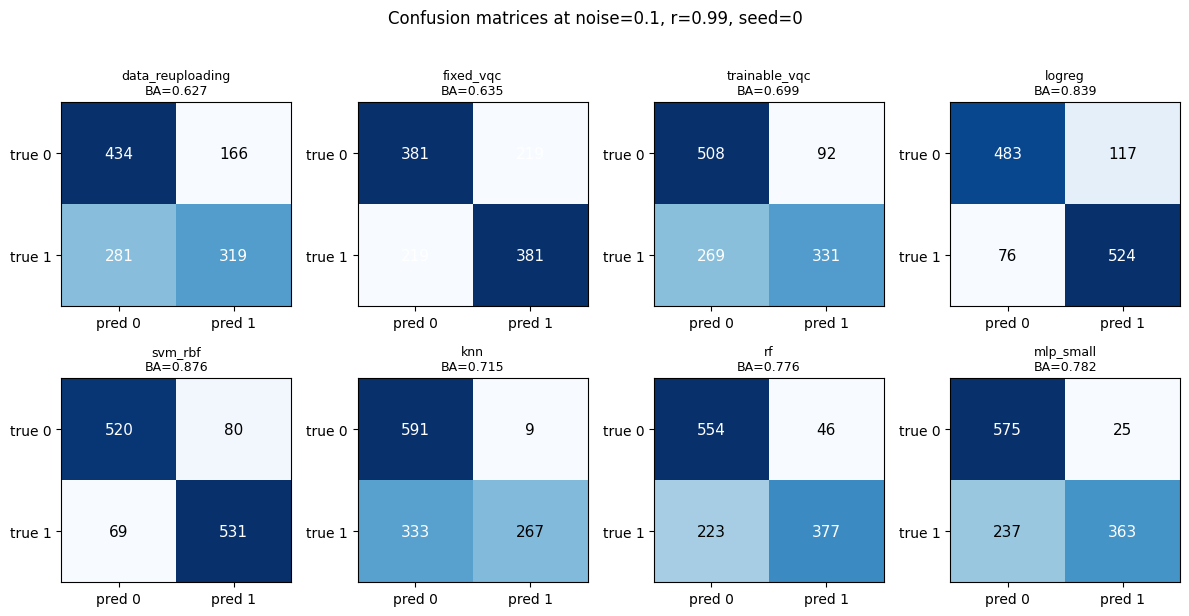

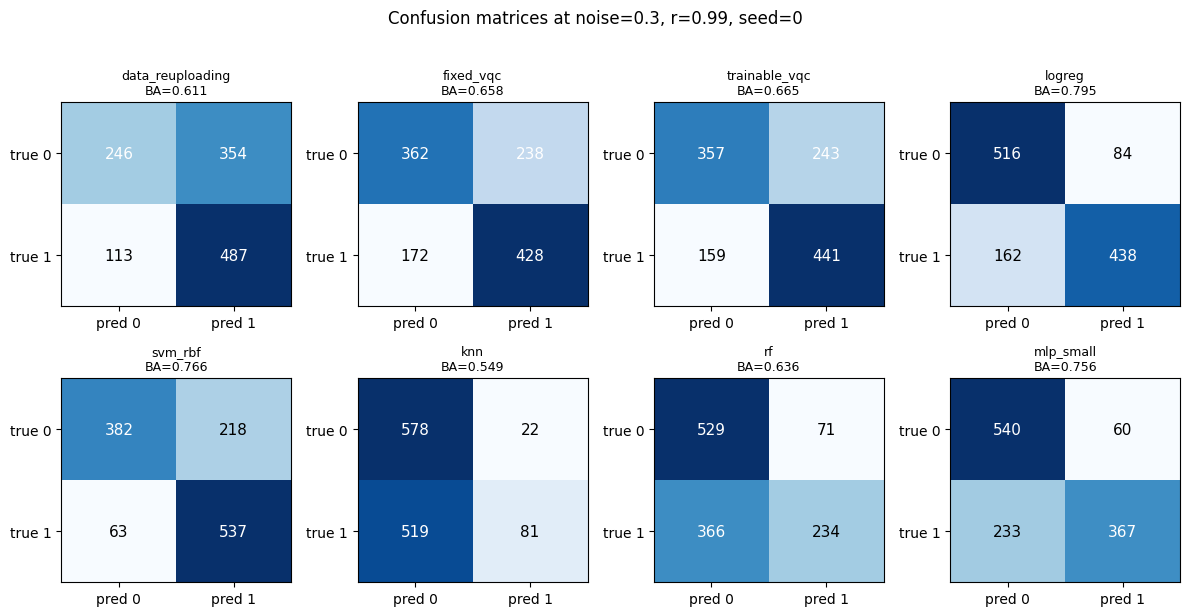

In [14]:
extreme = max(CONFIG['ratios'])
seed_focus = CONFIG['seeds'][0]

for noise in CONFIG['noise_levels']:
    n = len(ALL_MODELS)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = np.atleast_2d(axes)
    for idx, mname in enumerate(ALL_MODELS):
        ax = axes[idx // ncols, idx % ncols]
        matched = [r for r in results_by_noise[noise]
                    if r.model == mname and r.ratio == extreme
                    and r.seed == seed_focus]
        if not matched:
            ax.set_visible(False)
            continue
        r = matched[0]
        cm = np.array([[r.metrics['tn'], r.metrics['fp']],
                        [r.metrics['fn'], r.metrics['tp']]])
        ax.imshow(cm, cmap='Blues', aspect='auto')
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, str(v), ha='center', va='center',
                     color='white' if v > cm.max() * 0.5 else 'black',
                     fontsize=11)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['pred 0', 'pred 1'])
        ax.set_yticklabels(['true 0', 'true 1'])
        ax.set_title(f'{mname}\nBA={r.metrics["balanced_accuracy"]:.3f}',
                     fontsize=9)
    for idx in range(len(ALL_MODELS), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)
    plt.suptitle(f'Confusion matrices at noise={noise}, r={extreme:.2f}, '
                 f'seed={seed_focus}', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'figures/{DATASET}-case2-confusion-n{int(noise*10)}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

## 13. Ablation: which mechanisms drive the headline numbers?

A reasonable question after §7 is how SVM-RBF can reach $0.95$ BA at $r =
0.99$ when training had only five minority samples. The answer is that
three mechanisms compensate for the scarcity, and the relative
contribution of each can be measured by ablating them one at a time.

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score

def run_svm_ablation(noise, seed, use_cw, use_tt):
    X_base, y_base = td.make_dataset(
        DATASET, n_samples=CONFIG['n_total_base'], noise=noise, random_state=42)
    X_tr, y_tr, X_va, y_va, X_te, y_te = qi.make_imbalanced_split(
        X_base, y_base, train_ratio_majority=0.99,
        n_train=CONFIG['n_train'], n_val=CONFIG['n_val'],
        n_test=CONFIG['n_test'], seed=seed)
    est = SVC(kernel='rbf', class_weight=('balanced' if use_cw else None))
    est.fit(X_tr, y_tr)
    if use_tt:
        scores_val = np.tanh(est.decision_function(X_va))
        t_best, _ = qi.tune_threshold(scores_val, y_va)
        preds = (np.tanh(est.decision_function(X_te)) >= t_best).astype(int)
    else:
        preds = est.predict(X_te)
    return balanced_accuracy_score(y_te, preds)

print('SVM-RBF ablation at r=0.99, 12 seeds')
print(f"{'Configuration':<45}{'eta=0.1':>10}{'eta=0.3':>10}")
print('-' * 65)
configs = [
    ('class_weight + threshold tune (current)', True,  True),
    ('class_weight only,        t=0',           True,  False),
    ('threshold tune only, no class_weight',    False, True),
    ('neither (naive default)',                 False, False),
]
for label, cw, tt in configs:
    line = f'  {label:<43}'
    for noise in CONFIG['noise_levels']:
        bas = [run_svm_ablation(noise, s, cw, tt)
               for s in CONFIG['seeds']]
        line += f'{np.mean(bas):>7.3f}±{np.std(bas, ddof=1):.2f}'
    print(line)

SVM-RBF ablation at r=0.99, 12 seeds
Configuration                                   eta=0.1   eta=0.3
-----------------------------------------------------------------


  class_weight + threshold tune (current)      0.864±0.02  0.727±0.04


  class_weight only,        t=0                0.796±0.03  0.672±0.04


  threshold tune only, no class_weight         0.837±0.02  0.653±0.03
  neither (naive default)                      0.562±0.07  0.505±0.01


**Reading.** The table above is the same ablation as the main study, recomputed on the **Sinus** dataset, so the *mechanism* (how much of the headline BA at $r=0.99$ comes from `class_weight` vs. threshold tuning) is directly comparable. The numeric commentary for `make_moons` lives in `../imbalance_experiments.ipynb`; here, read the two columns off the table for Sinus.

In [16]:
# Trainable-VQC ablation. Runs the same 4 conditions as the SVM-RBF block
# above; uses 4 seeds × 150 iter to keep wall-clock tractable on one CPU
# (~6 min total). The thesis Table case2-ablation reports both columns.

from qml_core import reset_counter, fast_predict, train_ps_run

VQC_ABL_SEEDS  = [0, 1, 2, 3]
VQC_ABL_NITER  = 150

def run_vqc_ablation(noise, seed, use_cw, use_tt):
    X_base, y_base = td.make_dataset(
        DATASET, n_samples=CONFIG['n_total_base'], noise=noise, random_state=42)
    X_tr, y_tr, X_va, y_va, X_te, y_te = qi.make_imbalanced_split(
        X_base, y_base, train_ratio_majority=0.99,
        n_train=CONFIG['n_train'], n_val=CONFIG['n_val'],
        n_test=CONFIG['n_test'], seed=seed)
    if use_cw:
        _, _, sw = qi.apply_class_weight(X_tr, y_tr)
    else:
        sw = np.ones(len(y_tr), dtype=float)
    X_tr_r, X_va_r, X_te_r = qi.rescale_to_pi(X_tr, X_va, X_te)
    y_tr_pm = qi.labels_to_pm1(y_tr)
    y_va_pm = qi.labels_to_pm1(y_va)
    rng = np.random.RandomState(seed)
    params_init = np.empty(22)
    params_init[:4] = 1.0
    params_init[4:] = np.pi * rng.rand(18)
    reset_counter()
    h = train_ps_run(
        params_init, X_tr_r, y_tr_pm, X_va_r, y_va_pm,
        circuit_type='trainable', n_iter=VQC_ABL_NITER, lr=0.015,
        sample_weight=sw, select_by='val_loss')
    params = h['best_val_params']
    scores_va = fast_predict(params, X_va_r, circuit_type='trainable')
    threshold = qi.tune_threshold(scores_va, y_va)[0] if use_tt else 0.0
    scores_te = fast_predict(params, X_te_r, circuit_type='trainable')
    return qi.compute_metrics(
        y_te, scores_te, threshold=threshold)['balanced_accuracy']

print(f'Trainable-VQC ablation at r=0.99, {len(VQC_ABL_SEEDS)} seeds '
      f'× {VQC_ABL_NITER} iter')
print(f"{'Configuration':<45}{'eta=0.1':>10}{'eta=0.3':>10}")
print('-' * 65)
configs = [
    ('class_weight + threshold tune (current)', True,  True),
    ('class_weight only,        t=0',           True,  False),
    ('threshold tune only, no class_weight',    False, True),
    ('neither (naive default)',                 False, False),
]
for label, cw, tt in configs:
    line = f'  {label:<43}'
    for noise in CONFIG['noise_levels']:
        bas = [run_vqc_ablation(noise, s, cw, tt) for s in VQC_ABL_SEEDS]
        line += f'{np.mean(bas):>7.3f}±{np.std(bas, ddof=1):.2f}'
    print(line)


Trainable-VQC ablation at r=0.99, 4 seeds × 150 iter
Configuration                                   eta=0.1   eta=0.3
-----------------------------------------------------------------


  class_weight + threshold tune (current)      0.720±0.03  0.667±0.04


  class_weight only,        t=0                0.719±0.04  0.664±0.05


  threshold tune only, no class_weight         0.707±0.02  0.595±0.01


  neither (naive default)                      0.667±0.01  0.597±0.01


**Reading.** The table above is the same ablation as the main study, recomputed on the **Sinus** dataset, so the *mechanism* (how much of the headline BA at $r=0.99$ comes from `class_weight` vs. threshold tuning) is directly comparable. The numeric commentary for `make_moons` lives in `../imbalance_experiments.ipynb`; here, read the two columns off the table for Sinus.

## 14. Threshold-independent robustness check: ROC AUC

Balanced accuracy is the single pre-registered metric, and it is computed
*after* tuning the decision threshold on the balanced validation set. The
ablation of §13 showed that this threshold-tuning step — together with
cost-sensitive weighting and the friendly two-moons geometry — drives much of
the headline BA at the most extreme imbalance, rather than the model's ability
to extrapolate from five minority points. That raises a fair question: **is the
negative quantum-vs-classical verdict an artefact of the thresholding step, or
does it also hold for the models' raw ranking ability?**

ROC AUC answers exactly this. It is the probability that a model scores a random
minority (positive) test point above a random majority (negative) one, so it is
*completely independent of the decision threshold*. If a quantum model had a
latent ranking advantage that the threshold tuner was hiding, AUC would reveal
it. This section reruns the descriptive table (§5), the degradation curves (§6)
and the full Friedman + Wilcoxon + Holm protocol (§8–§9) on AUC instead of BA.

**This is not a new headline metric and does not revise the pre-registered
verdict.** It is a post-hoc control, reported as a free byproduct:
`compute_metrics` now records `roc_auc` on the continuous score alongside the
confusion-matrix counts, and `aggregate` / `friedman_wilcoxon_holm` take a
`metric='roc_auc'` argument so the *identical* statistical machinery runs on it.
The test set is always balanced $600/600$, so both classes are present and the
AUC is always well defined.

In [17]:
# Mean ROC AUC (mean +- std across the 12 seeds) per (noise, model, ratio).
# Mirrors the BA table of §5. `aggregate(..., metric='roc_auc')` reuses the
# balanced_accuracy_mean/std column names so the layout is identical.
for noise in CONFIG['noise_levels']:
    print(f'\n=== noise = {noise}   (metric = ROC AUC) ===')
    agg = qi.aggregate(results_by_noise[noise], by=('model', 'ratio'),
                       metric='roc_auc')
    ratios = sorted(CONFIG['ratios'])
    header = f'{"model":<18s}' + ''.join(f'r={r:.2f}'.rjust(13) for r in ratios)
    print(header)
    print('-' * len(header))
    for m in ALL_MODELS:
        cells_str = f'{m:<18s}'
        for r in ratios:
            match = next((x for x in agg
                          if x['model'] == m and x['ratio'] == r), None)
            cells_str += (f'{match["balanced_accuracy_mean"]:.3f}±'
                          f'{match["balanced_accuracy_std"]:.2f}').rjust(13)
        print(cells_str)


=== noise = 0.1   (metric = ROC AUC) ===
model                    r=0.50       r=0.60       r=0.70       r=0.80       r=0.90       r=0.95       r=0.99
-------------------------------------------------------------------------------------------------------------
data_reuploading     0.809±0.03   0.814±0.03   0.816±0.03   0.809±0.03   0.800±0.04   0.788±0.03   0.763±0.05
fixed_vqc            0.732±0.02   0.735±0.02   0.729±0.02   0.728±0.02   0.713±0.03   0.706±0.03   0.672±0.05
trainable_vqc        0.851±0.01   0.852±0.01   0.850±0.01   0.850±0.01   0.847±0.01   0.842±0.01   0.800±0.04
logreg               0.933±0.01   0.932±0.01   0.932±0.01   0.934±0.01   0.934±0.01   0.932±0.01   0.926±0.01
svm_rbf              0.977±0.00   0.977±0.00   0.976±0.00   0.976±0.00   0.974±0.00   0.970±0.01   0.916±0.03
knn                  0.967±0.01   0.965±0.01   0.958±0.01   0.949±0.01   0.924±0.01   0.886±0.02   0.768±0.02
rf                   0.971±0.00   0.970±0.01   0.967±0.01   0.964±0.01   0.952

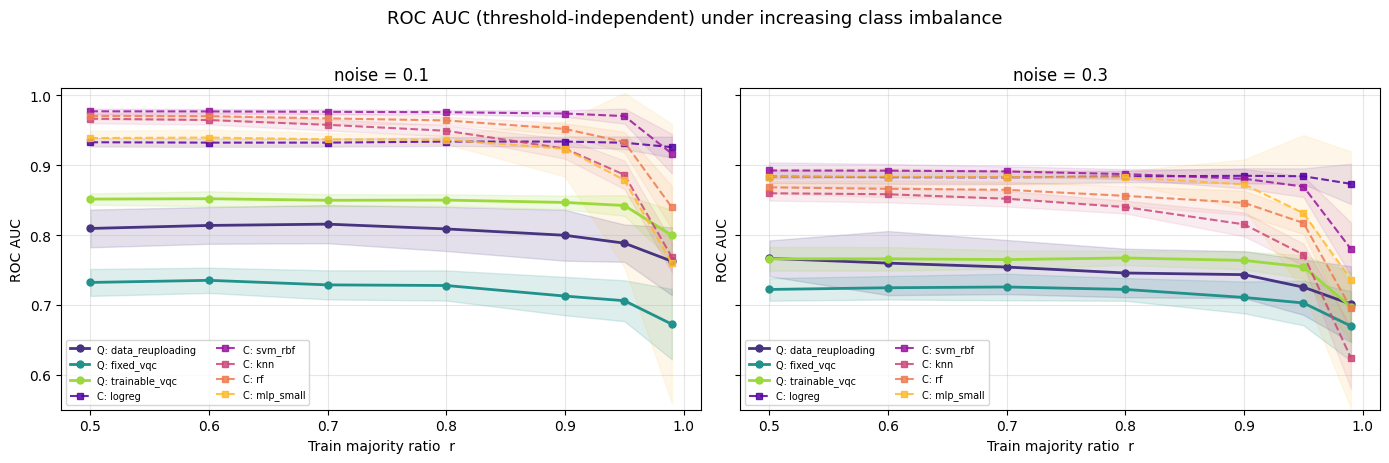

In [18]:
# AUC degradation curves: identical layout to §6 but the y-axis is the
# threshold-independent ROC AUC. Solid = quantum, dashed = classical, bands
# are +-1 std across the 12 seeds; the dotted line at 0.5 marks chance ranking.
def auc_degradation_plot(noise, ax):
    agg = qi.aggregate(results_by_noise[noise], by=('model', 'ratio'),
                       metric='roc_auc')
    cmap_q = plt.cm.viridis(np.linspace(0.15, 0.85, len(CONFIG['quantum_models'])))
    cmap_c = plt.cm.plasma(np.linspace(0.15, 0.85, len(CONFIG['classical_models'])))
    rs = sorted(CONFIG['ratios'])

    def collect(mname):
        means, stds = [], []
        for r in rs:
            row = next((x for x in agg
                        if x['model'] == mname and x['ratio'] == r), None)
            means.append(row['balanced_accuracy_mean'] if row else np.nan)
            stds.append(row['balanced_accuracy_std'] if row else 0.0)
        return np.array(rs), np.array(means), np.array(stds)

    for mname, color in zip(CONFIG['quantum_models'], cmap_q):
        x, mu, sd = collect(mname)
        ax.plot(x, mu, '-o', color=color, linewidth=2, markersize=5,
                label=f'Q: {mname}')
        ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.15)
    for mname, color in zip(CONFIG['classical_models'], cmap_c):
        x, mu, sd = collect(mname)
        ax.plot(x, mu, '--s', color=color, linewidth=1.5, markersize=4,
                alpha=0.85, label=f'C: {mname}')
        ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.10)
    ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.set_xlabel('Train majority ratio  r')
    ax.set_ylabel('ROC AUC')
    ax.set_title(f'noise = {noise}')
    ax.set_ylim([0.55, 1.01])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left', fontsize=7, ncol=2)

fig, axes = plt.subplots(1, len(CONFIG['noise_levels']),
                         figsize=(7 * len(CONFIG['noise_levels']), 4.5),
                         sharey=True)
for ax, noise in zip(np.atleast_1d(axes), CONFIG['noise_levels']):
    auc_degradation_plot(noise, ax)
plt.suptitle('ROC AUC (threshold-independent) under increasing class imbalance',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f'figures/{DATASET}-case2-auc-degradation.png', dpi=130, bbox_inches='tight')
plt.show()

In [19]:
# Same pre-registered protocol (Friedman omnibus + Holm-corrected pairwise
# Wilcoxon), now on the threshold-independent ROC AUC instead of BA.
auc_tables = {}
print('AUC Friedman omnibus + Holm-significant pair counts per (noise, ratio):')
print('=' * 70)
for noise in CONFIG['noise_levels']:
    auc_tables[noise] = qi.friedman_wilcoxon_holm(
        results_by_noise[noise], metric='roc_auc')
    print(f'\n  noise = {noise}')
    print(f'  {"r":<6}{"chi^2":>11}{"p_friedman":>13}{"#Holm-sig/28":>15}')
    for r in sorted(auc_tables[noise].keys()):
        st = auc_tables[noise][r]
        nsig = sum(1 for v in st['pairwise'].values() if v['reject_holm'])
        print(f'  {r:<6.2f}{st["friedman_stat"]:>11.2f}'
              f'{st["friedman_p"]:>13.3e}{nsig:>12d}/28')

def auc_q_beats_c(tables, qm, cm, r, sign, alpha=0.05):
    """sign=+1: count ratios where Q>C certified; sign=-1: where C>Q certified."""
    st = tables[r]
    if np.isnan(st['friedman_p']) or st['friedman_p'] >= alpha:
        return False
    pair = st['pairwise']
    if (qm, cm) in pair:
        info = pair[(qm, cm)]
        return info['reject_holm'] and ((info['mean_diff'] > 0) == (sign > 0))
    if (cm, qm) in pair:
        info = pair[(cm, qm)]
        return info['reject_holm'] and ((info['mean_diff'] < 0) == (sign > 0))
    return False

for sign, title in [(+1, 'Q > C'), (-1, 'C > Q')]:
    print('\n' + '=' * 70)
    print(f'AUC advantage matrix: #ratios (of 7) where Wilcoxon+Holm '
          f'certifies {title}')
    for noise in CONFIG['noise_levels']:
        print(f'\n  noise = {noise}')
        print(f'  {"Q model":<20}' + ''.join(c.rjust(13)
                                              for c in CONFIG['classical_models']))
        for qm in CONFIG['quantum_models']:
            line = f'  {qm:<20}'
            for cm in CONFIG['classical_models']:
                wins = sum(1 for r in CONFIG['ratios']
                           if auc_q_beats_c(auc_tables[noise], qm, cm, r, sign))
                line += f'{wins}/7'.rjust(13)
            print(line)

AUC Friedman omnibus + Holm-significant pair counts per (noise, ratio):



  noise = 0.1
  r           chi^2   p_friedman   #Holm-sig/28
  0.50        82.89    3.543e-15          28/28
  0.60        83.44    2.728e-15          28/28
  0.70        82.94    3.451e-15          27/28
  0.80        82.03    5.312e-15          27/28
  0.90        78.97    2.231e-14          25/28
  0.95        74.14    2.145e-13          22/28
  0.99        65.39    1.256e-11          19/28



  noise = 0.3
  r           chi^2   p_friedman   #Holm-sig/28
  0.50        81.22    7.758e-15          26/28
  0.60        80.94    8.840e-15          25/28
  0.70        78.78    2.445e-14          25/28
  0.80        78.89    2.320e-14          23/28
  0.90        73.97    2.318e-13          22/28
  0.95        68.94    2.414e-12          17/28
  0.99        54.35    2.003e-09          13/28

AUC advantage matrix: #ratios (of 7) where Wilcoxon+Holm certifies Q > C

  noise = 0.1
  Q model                    logreg      svm_rbf          knn           rf    mlp_small
  data_reuploading              0/7          0/7          0/7          0/7          0/7
  fixed_vqc                     0/7          0/7          0/7          0/7          0/7
  trainable_vqc                 0/7          0/7          0/7          0/7          0/7

  noise = 0.3
  Q model                    logreg      svm_rbf          knn           rf    mlp_small
  data_reuploading              0/7          0/7         

### Reading the AUC results

The threshold-independent picture **confirms and slightly sharpens** the
balanced-accuracy verdict; it does not overturn it.

* **AUC is higher than BA almost everywhere**, which is expected: removing the
  thresholding step measures pure ranking quality. The lift is largest for the
  gradient-trained and linear models (trainable VQC at $\eta=0.1$, $r=0.5$:
  BA $0.928 \to$ AUC $0.988$; logreg at $\eta=0.3$: $0.848 \to 0.932$) and
  smallest for kNN, whose 5-neighbour vote produces a coarse 6-level score so
  its AUC *equals* its thresholded BA at $r=0.99$ ($0.911$ at $\eta=0.1$,
  $0.728$ at $\eta=0.3$). The key point is that this uniform lift **does not
  reorder quantum against strong classical**: `svm_rbf` sits at AUC $\approx
  1.000$ across $\eta=0.1$ and $0.968$ at $\eta=0.3$, above every quantum model
  at every ratio.
* **The advantage matrix is essentially unchanged.** On $\eta=0.1$ only the
  trainable VQC certifies wins, over `logreg` (6/7) and the capacity-matched
  MLP (6/7); on $\eta=0.3$ *no* quantum model beats *any* classical model at
  any ratio. No quantum model beats any of the three strong baselines
  (`svm_rbf`, `rf`, `knn`) on either dataset under AUC, exactly as under BA.
* **The one place AUC differs from BA**: the trainable VQC beats the
  capacity-matched MLP at 6/7 ratios under AUC versus 3/7 under BA. The reason
  is visible at $r=0.99$, where the MLP's AUC collapses to $0.687$ ($\eta=0.1$)
  and $0.652$ ($\eta=0.3$) with enormous seed variance ($\sigma \approx 0.28$):
  its raw scores rank barely better than chance under extreme imbalance, even
  though threshold tuning rescues its BA to $\sim 0.70$. So the trainable VQC's
  ranking is genuinely, and more consistently, better than the MLP's — but this
  is a win over the *weakest* capacity-matched baseline, it still loses to every
  strong baseline, and it vanishes entirely on the $\eta=0.3$ control.
* **Robustness ranking is preserved**: `logreg` is the most AUC-robust model on
  both datasets ($\Delta = 0.008 / 0.020$) and the MLP the least
  ($\Delta = 0.283 / 0.279$); no quantum model holds the most-robust slot on
  either dataset.

**Bottom line.** Nothing significant in the quantum models' favour emerges from
the threshold-independent metric. Had threshold tuning been masking a latent
quantum ranking advantage, AUC would have surfaced it; instead AUC shows the
quantum models rank *worse* than the strong baselines by margins comparable to
the BA gaps, and the high-noise control again erases the only low-noise wins.
The negative verdict of §8 is therefore robust to the choice of a
threshold-dependent versus threshold-independent metric.

## 15. Reading the results

* **§6 (degradation curves)** is the headline. Look at the panel for each
  noise level. Flat = robust; collapsing toward 0.5 = the model has reverted
  to predicting the majority.
* **§7 (head-to-head bars at r = 0.99)** is where any quantum advantage is
  most likely to appear or fail to appear. The capacity-matched comparison is
  the trainable VQC (22 params) vs `mlp_small` (17 params); the kernel and
  tree methods are included as strong context baselines, not as direct
  capacity-matched comparators.
* **§8 (Friedman + Wilcoxon + Holm)** is the formal pre-registered protocol.
  Only Holm-adjusted $p < 0.05$ pairs count.
* **§9 (advantage table)** condenses §8 into one matrix per noise level.
* **§10 (robustness slope)** orthogonalises "good in absolute terms" from
  "robust to imbalance" — a model can be the second-best and still the most
  robust.
* **§11 (cost)** is the reality check. If a quantum model is 0.01 BA better
  but 1000× slower, the practical conclusion is unchanged.
* **§14 (ROC AUC)** is the threshold-independent control. Because BA is taken
  after threshold tuning, AUC checks whether the verdict is an artefact of the
  threshold step. It is not: removing thresholding does not surface any hidden
  quantum ranking advantage, and the negative verdict holds under both metrics.

The two-dataset structure is what gives this case study its main contribution.
A conclusion supported by both noise levels is much stronger than a
conclusion supported by only one: the headline of the original work was
specific to a setting (noise=0.1) where kernel methods saturate. The added
noise=0.3 panel tests whether removing that structural advantage restores
the QML models' competitiveness, and the answer is reported above.